# Session 7 - NumPy

NumPy (Numerical Python) is the foundation of the entire Python data science ecosystem. pandas, scikit-learn, matplotlib — they all build on top of NumPy arrays under the hood. Understanding NumPy well will make everything else easier.

At its core, NumPy provides a powerful **array object** that's much faster and more convenient than Python lists for numerical work. The key difference? NumPy arrays are:

- **Homogeneous** — all elements must be the same type
- **Fixed-size** — you can't append/pop like lists
- **Vectorized** — operations happen in compiled C code, not slow Python loops

Let's see why that matters.

In [1]:
import numpy as np

## Why NumPy? Speed Comparison

Let's compare adding up a million numbers using a Python list vs a NumPy array:

In [2]:
import timeit

# Python list approach
python_list = list(range(1_000_000))
python_time = timeit.timeit(lambda: sum(python_list), number=100)

# NumPy array approach
numpy_array = np.arange(1_000_000)
numpy_time = timeit.timeit(lambda: np.sum(numpy_array), number=100)

print(f"Python list sum:  {python_time:.4f}s")
print(f"NumPy array sum:  {numpy_time:.4f}s")
print(f"NumPy is {python_time/numpy_time:.0f}x faster!")

Python list sum:  0.4262s
NumPy array sum:  0.0102s
NumPy is 42x faster!


That speed difference only gets bigger as your data grows. Now let's learn how to use it.

## Creating Arrays

The most basic way to create an array is from a Python list:

In [3]:
# 1-D array (like a vector)
a = np.array([1, 2, 3])
print(f"Array a: {a}")
print(f"Type: {type(a)}")
print(f"Shape: {a.shape}")  # (3,) means 1-dimensional with 3 elements
print(f"Data type: {a.dtype}")

# Modify elements
a[0] = 5
print(f"\nAfter a[0] = 5: {a}")

Array a: [1 2 3]
Type: <class 'numpy.ndarray'>
Shape: (3,)
Data type: int64

After a[0] = 5: [5 2 3]


In [4]:
# 2-D array (like a matrix)
b = np.array([[1, 2, 3],
              [4, 5, 6]])
print(f"Array b:\n{b}")
print(f"Shape: {b.shape}")  # (2, 3) means 2 rows, 3 columns

Array b:
[[1 2 3]
 [4 5 6]]
Shape: (2, 3)


### Array Creation Functions

NumPy provides convenient functions to create common arrays:

In [5]:
zeros = np.zeros((2, 3))
print(f"Zeros:\n{zeros}\n")

ones = np.ones((1, 4))
print(f"Ones:\n{ones}\n")

full = np.full((2, 2), 7)
print(f"Full of 7s:\n{full}\n")

identity = np.eye(3)
print(f"Identity (3x3):\n{identity}\n")

random_arr = np.random.random((2, 3))
print(f"Random values:\n{random_arr}\n")

arange = np.arange(0, 10, 2)  # Like Python's range()
print(f"Arange (0 to 10, step 2): {arange}\n")

linspace = np.linspace(0, 1, 5)  # 5 evenly spaced values from 0 to 1
print(f"Linspace (0 to 1, 5 points): {linspace}")

Zeros:
[[0. 0. 0.]
 [0. 0. 0.]]

Ones:
[[1. 1. 1. 1.]]

Full of 7s:
[[7 7]
 [7 7]]

Identity (3x3):
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

Random values:
[[0.50545227 0.00703475 0.95159399]
 [0.63118995 0.58535496 0.1374021 ]]

Arange (0 to 10, step 2): [0 2 4 6 8]

Linspace (0 to 1, 5 points): [0.   0.25 0.5  0.75 1.  ]


In [6]:
# Test: Verify array creation functions
assert np.zeros((2, 2)).shape == (2, 2)
assert np.ones((3,)).sum() == 3.0
assert np.full((2, 2), 5).mean() == 5.0
assert np.eye(3).trace() == 3.0  # Trace = sum of diagonal
assert len(np.arange(0, 10, 2)) == 5
assert len(np.linspace(0, 1, 5)) == 5
assert np.linspace(0, 1, 5)[0] == 0.0
assert np.linspace(0, 1, 5)[-1] == 1.0
print("Array creation tests passed!")

Array creation tests passed!


### Specifying Data Types

Every NumPy array has a single data type. NumPy usually guesses correctly, but you can force it:

In [7]:
x = np.array([1, 2, 3])              # NumPy chooses int64
y = np.array([1.0, 2.0, 3.0])        # NumPy chooses float64
z = np.array([1, 2, 3], dtype=np.int32)  # Forced to 32-bit int
w = np.array([1, 2, 3], dtype=np.float64)  # Forced to 64-bit float

print(f"x dtype: {x.dtype}")
print(f"y dtype: {y.dtype}")
print(f"z dtype: {z.dtype}")
print(f"w dtype: {w.dtype}")

x dtype: int64
y dtype: float64
z dtype: int32
w dtype: float64


## Array Indexing

NumPy gives you several powerful ways to access array elements. We'll cover three: slicing, integer indexing, and boolean indexing.

We'll use this array as our example:

| | Col 0 | Col 1 | Col 2 | Col 3 |
|---|---|---|---|---|
| **Row 0** | 1 | 2 | 3 | 4 |
| **Row 1** | 5 | 6 | 7 | 8 |
| **Row 2** | 9 | 10 | 11 | 12 |

In [8]:
a = np.array([[1, 2, 3, 4],
              [5, 6, 7, 8],
              [9, 10, 11, 12]])
print(a)

[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]


### Slicing

Slicing works like Python lists, but for each dimension:

In [9]:
# Get rows 0-1, columns 1-2
b = a[:2, 1:3]
print(f"a[:2, 1:3]:\n{b}")

a[:2, 1:3]:
[[2 3]
 [6 7]]


> **Important:** A slice returns a *view* into the original array — not a copy. Modifying the slice modifies the original!

In [10]:
print(f"Before: a[0, 1] = {a[0, 1]}")
b[0, 0] = 77  # This modifies the original array!
print(f"After modifying b: a[0, 1] = {a[0, 1]}")

Before: a[0, 1] = 2
After modifying b: a[0, 1] = 77


If you need a copy, use `.copy()`:

In [11]:
# Reset the array
a = np.array([[1, 2, 3, 4],
              [5, 6, 7, 8],
              [9, 10, 11, 12]])

# Create a copy instead of a view
c = a[:2, 1:3].copy()
c[0, 0] = 99
print(f"After modifying copy: a[0, 1] = {a[0, 1]}  (unchanged)")

After modifying copy: a[0, 1] = 2  (unchanged)


### Rank: Slices vs Integer Indexing

Mixing integer indices with slices reduces the array's rank (dimensions). This is a common gotcha:

In [12]:
a = np.array([[1, 2, 3, 4],
              [5, 6, 7, 8],
              [9, 10, 11, 12]])

# Integer index → rank 1 (flat array)
row_r1 = a[1, :]
print(f"a[1, :] → shape {row_r1.shape}: {row_r1}")

# Slice → rank 2 (still a matrix)
row_r2 = a[1:2, :]
print(f"a[1:2, :] → shape {row_r2.shape}:\n{row_r2}")

a[1, :] → shape (4,): [5 6 7 8]
a[1:2, :] → shape (1, 4):
[[5 6 7 8]]


The same applies to columns:

In [13]:
col_r1 = a[:, 1]     # Rank 1
col_r2 = a[:, 1:2]   # Rank 2
print(f"a[:, 1] → shape {col_r1.shape}: {col_r1}")
print(f"a[:, 1:2] → shape {col_r2.shape}:\n{col_r2}")

a[:, 1] → shape (3,): [ 2  6 10]
a[:, 1:2] → shape (3, 1):
[[ 2]
 [ 6]
 [10]]


In [14]:
# Test: Verify slicing and view behavior
arr = np.array([[1, 2, 3], [4, 5, 6]])

# Slicing returns a view
view = arr[:1, :]
view[0, 0] = 99
assert arr[0, 0] == 99, "View should modify original"

# Copy is independent
copy = arr[:1, :].copy()
copy[0, 0] = 0
assert arr[0, 0] == 99, "Copy should not affect original"

# Shape differences
assert arr[0, :].shape == (3,)      # Rank 1
assert arr[0:1, :].shape == (1, 3)  # Rank 2
print("Slicing tests passed!")

Slicing tests passed!


### Integer Array Indexing

Slicing always gives you subarrays. Integer array indexing lets you pick *specific* elements to build a completely new array:

In [15]:
a = np.array([[1, 2],
              [3, 4],
              [5, 6]])

# Pick elements at (0,0), (1,1), (2,0)
b = a[[0, 1, 2], [0, 1, 0]]
print(f"Integer indexed: {b}")  # [1, 4, 5]

# This is equivalent to:
print(f"Manual indexing: {np.array([a[0, 0], a[1, 1], a[2, 0]])}")

Integer indexed: [1 4 5]
Manual indexing: [1 4 5]


Unlike slicing, integer array indexing creates a **copy** — modifying the original won't affect the result:

In [16]:
a[1, 1] = 9000
print(f"After modifying a[1,1]: b = {b}  (unchanged)")

After modifying a[1,1]: b = [1 4 5]  (unchanged)


You can also reuse the same element multiple times:

In [17]:
print(f"Reuse element: {a[[0, 0, 2], [1, 1, 0]]}")  # [2, 2, 5]

Reuse element: [2 2 5]


#### Practical Use: Select One Element Per Row

A very common pattern — picking one value from each row based on column indices:

In [18]:
a = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9],
              [10, 11, 12]])

# Column index to pick from each row
col_indices = np.array([0, 2, 0, 1])

# Pick one element per row
selected = a[np.arange(4), col_indices]
print(f"Selected: {selected}")  # [1, 6, 7, 11]

# We can also modify these in place
a[np.arange(4), col_indices] += 10
print(f"After adding 10:\n{a}")

Selected: [ 1  6  7 11]
After adding 10:
[[11  2  3]
 [ 4  5 16]
 [17  8  9]
 [10 21 12]]


In [19]:
# Test: Verify integer array indexing
arr = np.array([[1, 2], [3, 4], [5, 6]])

# Integer indexing returns a copy
result = arr[[0, 2], [1, 0]]
assert np.array_equal(result, np.array([2, 5]))

# Modifying original doesn't affect result
arr[0, 1] = 99
assert result[0] == 2, "Integer indexing should return a copy"

# Select one per row pattern
matrix = np.array([[10, 20, 30], [40, 50, 60]])
indices = np.array([2, 0])
assert np.array_equal(matrix[np.arange(2), indices], np.array([30, 40]))
print("Integer array indexing tests passed!")

Integer array indexing tests passed!


### Boolean Array Indexing

This is perhaps the most useful indexing method. You create a True/False mask and use it to filter elements:

In [20]:
a = np.array([[1, 2],
              [3, 4],
              [5, 6]])

# Create a boolean mask
bool_idx = a > 2
print(f"Boolean mask (a > 2):\n{bool_idx}")

Boolean mask (a > 2):
[[False False]
 [ True  True]
 [ True  True]]


In [21]:
# Use the mask to filter
print(f"Elements > 2: {a[bool_idx]}")

# Or do it in one step:
print(f"Elements > 2 (one-liner): {a[a > 2]}")

Elements > 2: [3 4 5 6]
Elements > 2 (one-liner): [3 4 5 6]


This is how you'll filter data in real projects — no loops needed.

In [22]:
# Test: Verify boolean array indexing
arr = np.array([1, 2, 3, 4, 5, 6])
assert np.array_equal(arr[arr > 3], np.array([4, 5, 6]))
assert np.array_equal(arr[arr % 2 == 0], np.array([2, 4, 6]))
assert np.array_equal(arr[(arr > 2) & (arr < 6)], np.array([3, 4, 5]))  # Compound condition
print("Boolean array indexing tests passed!")

Boolean array indexing tests passed!


## Array Math

Basic math operations in NumPy work elementwise — both with operators and functions:

In [23]:
x = np.array([[1, 2],
              [3, 4]], dtype=np.float64)
y = np.array([[5, 6],
              [7, 8]], dtype=np.float64)

print("Addition:")
print(f"x + y:\n{x + y}")
print(f"np.add(x, y):\n{np.add(x, y)}\n")

print("Subtraction:")
print(f"x - y:\n{x - y}")
print(f"np.subtract(x, y):\n{np.subtract(x, y)}\n")

print("Multiplication (elementwise, NOT matrix multiplication):")
print(f"x * y:\n{x * y}")
print(f"np.multiply(x, y):\n{np.multiply(x, y)}\n")

print("Division:")
print(f"x / y:\n{x / y}")
print(f"np.divide(x, y):\n{np.divide(x, y)}\n")

print("Square root:")
print(f"np.sqrt(x):\n{np.sqrt(x)}")

Addition:
x + y:
[[ 6.  8.]
 [10. 12.]]
np.add(x, y):
[[ 6.  8.]
 [10. 12.]]

Subtraction:
x - y:
[[-4. -4.]
 [-4. -4.]]
np.subtract(x, y):
[[-4. -4.]
 [-4. -4.]]

Multiplication (elementwise, NOT matrix multiplication):
x * y:
[[ 5. 12.]
 [21. 32.]]
np.multiply(x, y):
[[ 5. 12.]
 [21. 32.]]

Division:
x / y:
[[0.2        0.33333333]
 [0.42857143 0.5       ]]
np.divide(x, y):
[[0.2        0.33333333]
 [0.42857143 0.5       ]]

Square root:
np.sqrt(x):
[[1.         1.41421356]
 [1.73205081 2.        ]]


### Matrix Multiplication

Remember: `*` is elementwise! For proper matrix multiplication, use `@` or `np.dot()`:

In [24]:
x = np.array([[1, 2],
              [3, 4]])
y = np.array([[5, 6],
              [7, 8]])

v = np.array([9, 10])
w = np.array([11, 12])

# Vector dot product
print(f"v · w = {v @ w}")  # or np.dot(v, w) or v.dot(w)

# Matrix-vector product
print(f"x @ v = {x @ v}")

# Matrix-matrix product
print(f"x @ y:\n{x @ y}")

v · w = 219
x @ v = [29 67]
x @ y:
[[19 22]
 [43 50]]


In [25]:
# Test: Verify array math operations
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

# Elementwise operations
assert np.array_equal(a + b, np.array([5, 7, 9]))
assert np.array_equal(a * b, np.array([4, 10, 18]))
assert np.array_equal(a * 2, np.array([2, 4, 6]))

# Matrix multiplication
m = np.array([[1, 2], [3, 4]])
v = np.array([1, 1])
assert np.array_equal(m @ v, np.array([3, 7]))

# sqrt
assert np.allclose(np.sqrt(np.array([4, 9, 16])), np.array([2, 3, 4]))
print("Array math tests passed!")

Array math tests passed!


### Aggregation Functions

NumPy provides fast functions for computing statistics across arrays:

In [26]:
x = np.array([[1, 2, 3],
              [4, 5, 6]])

print(f"Sum of all elements: {np.sum(x)}")
print(f"Sum of each column (axis=0): {np.sum(x, axis=0)}")
print(f"Sum of each row (axis=1): {np.sum(x, axis=1)}")
print()
print(f"Mean of all elements: {np.mean(x):.2f}")
print(f"Max value: {np.max(x)}")
print(f"Min value: {np.min(x)}")
print(f"Standard deviation: {np.std(x):.2f}")
print(f"Index of max value: {np.argmax(x)}")

Sum of all elements: 21
Sum of each column (axis=0): [5 7 9]
Sum of each row (axis=1): [ 6 15]

Mean of all elements: 3.50
Max value: 6
Min value: 1
Standard deviation: 1.71
Index of max value: 5


In [27]:
# Test: Verify aggregation functions
arr = np.array([[1, 2, 3], [4, 5, 6]])

assert np.sum(arr) == 21
assert np.mean(arr) == 3.5
assert np.max(arr) == 6
assert np.min(arr) == 1
assert np.array_equal(np.sum(arr, axis=0), np.array([5, 7, 9]))
assert np.array_equal(np.sum(arr, axis=1), np.array([6, 15]))
assert np.std(arr) > 0
print("Aggregation function tests passed!")

Aggregation function tests passed!


## Broadcasting

Broadcasting is NumPy's superpower. It lets you do math between arrays of different shapes *without* making copies.

The classic example: adding a vector to each row of a matrix.

In [28]:
x = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9],
              [10, 11, 12]])
v = np.array([1, 0, 1])

# The slow way (don't do this!)
y = np.empty_like(x)
for i in range(4):
    y[i] = x[i] + v
print(f"With loop:\n{y}")

With loop:
[[ 2  2  4]
 [ 5  5  7]
 [ 8  8 10]
 [11 11 13]]


In [29]:
# The broadcasting way (one line, much faster!)
y = x + v
print(f"With broadcasting:\n{y}")

With broadcasting:
[[ 2  2  4]
 [ 5  5  7]
 [ 8  8 10]
 [11 11 13]]


How does this work? NumPy "stretches" `v` (shape `(3,)`) to match `x` (shape `(4, 3)`) by virtually repeating it along the first dimension. No memory is actually used — it's all handled in C.

### Broadcasting Rules

1. If arrays have different ranks, prepend 1s to the smaller shape until they match
2. Two dimensions are compatible if they're equal, or one of them is 1
3. Arrays can broadcast if they're compatible in *all* dimensions

Examples:

In [30]:
# Outer product: (3,) × (2,) → (3, 2)
v = np.array([1, 2, 3])   # Shape (3,)
w = np.array([4, 5])      # Shape (2,)
outer = np.reshape(v, (3, 1)) * w  # Reshape to (3, 1), broadcast against (2,)
print(f"Outer product:\n{outer}\n")

# Add vector to each row: (2, 3) + (3,) → (2, 3)
x = np.array([[1, 2, 3], [4, 5, 6]])
v = np.array([10, 20, 30])
print(f"Row addition:\n{x + v}\n")

# Add vector to each column: (2, 3) + (2, 1) → (2, 3)
w = np.array([100, 200])
print(f"Column addition:\n{x + np.reshape(w, (2, 1))}\n")

# Multiply by scalar: (2, 3) × () → (2, 3)
print(f"Scalar multiplication:\n{x * 2}")

Outer product:
[[ 4  5]
 [ 8 10]
 [12 15]]

Row addition:
[[11 22 33]
 [14 25 36]]

Column addition:
[[101 102 103]
 [204 205 206]]

Scalar multiplication:
[[ 2  4  6]
 [ 8 10 12]]


In [31]:
# Test: Verify broadcasting rules
# Row vector + matrix
x = np.array([[1, 2, 3], [4, 5, 6]])
v = np.array([10, 20, 30])
result = x + v
assert np.array_equal(result, np.array([[11, 22, 33], [14, 25, 36]]))

# Column vector + matrix
c = np.array([[100], [200]])
result = x + c
assert np.array_equal(result, np.array([[101, 102, 103], [204, 205, 206]]))

# Outer product
a = np.array([1, 2, 3])
b = np.array([4, 5])
outer = np.reshape(a, (3, 1)) * b
assert outer.shape == (3, 2)
assert outer[0, 0] == 4  # 1 * 4
assert outer[2, 1] == 15  # 3 * 5
print("Broadcasting tests passed!")

Broadcasting tests passed!


## Reshaping and Transposing

Data often comes in the wrong shape. NumPy gives you tools to rearrange it:

In [32]:
a = np.arange(12)  # [0, 1, 2, ..., 11]
print(f"1D array: {a}\n")

# Reshape to 2D
b = a.reshape(3, 4)
print(f"Reshaped to (3, 4):\n{b}\n")

# Flatten back to 1D
print(f"Flattened: {b.flatten()}\n")

# Transpose (swap rows and columns)
print(f"Transposed:\n{b.T}")

1D array: [ 0  1  2  3  4  5  6  7  8  9 10 11]

Reshaped to (3, 4):
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]

Flattened: [ 0  1  2  3  4  5  6  7  8  9 10 11]

Transposed:
[[ 0  4  8]
 [ 1  5  9]
 [ 2  6 10]
 [ 3  7 11]]


In [33]:
# Test: Verify reshape and transpose
a = np.arange(6)
b = a.reshape(2, 3)
assert b.shape == (2, 3)
assert np.array_equal(b.flatten(), a)
assert b.T.shape == (3, 2)
assert b.T[0, 0] == b[0, 0]
assert b.T[1, 0] == b[0, 1]
print("Reshape and transpose tests passed!")

Reshape and transpose tests passed!


## Real-World Example 1: Image Data

Images are stored as NumPy arrays! A grayscale image is a 2D array (height × width), and a color image is 3D (height × width × 3 channels for RGB).

Let's simulate some image operations:

In [34]:
# Simulate a tiny 4x4 grayscale image (pixel values 0-255)
np.random.seed(42)
image = np.random.randint(0, 256, size=(4, 4), dtype=np.uint8)
print(f"Original image (4x4 grayscale):\n{image}\n")

# Brighten the image (add constant)
brighter = np.clip(image.astype(np.int16) + 50, 0, 255).astype(np.uint8)
print(f"Brightened (+50):\n{brighter}\n")

# Threshold: convert to binary (black/white)
binary = (image > 128).astype(np.uint8) * 255
print(f"Binary (threshold > 128):\n{binary}\n")

# Normalize to 0-1 range
normalized = image.astype(np.float64) / 255.0
print(f"Normalized (0-1 range):\n{normalized.round(2)}")

Original image (4x4 grayscale):
[[102 220 225  95]
 [179  61 234 203]
 [ 92   3  98 243]
 [ 14 149 245  46]]

Brightened (+50):
[[152 255 255 145]
 [229 111 255 253]
 [142  53 148 255]
 [ 64 199 255  96]]

Binary (threshold > 128):
[[  0 255 255   0]
 [255   0 255 255]
 [  0   0   0 255]
 [  0 255 255   0]]

Normalized (0-1 range):
[[0.4  0.86 0.88 0.37]
 [0.7  0.24 0.92 0.8 ]
 [0.36 0.01 0.38 0.95]
 [0.05 0.58 0.96 0.18]]


In [35]:
# Test: Verify image operations
img = np.array([[100, 200], [50, 150]], dtype=np.uint8)

# Threshold
binary = (img > 128).astype(np.uint8) * 255
assert np.array_equal(binary, np.array([[0, 255], [0, 255]], dtype=np.uint8))

# Normalization
normalized = img.astype(np.float64) / 255.0
assert normalized.min() >= 0.0
assert normalized.max() <= 1.0
assert np.allclose(normalized[0, 1], 200/255, atol=0.01)
print("Image operation tests passed!")

Image operation tests passed!


## Real-World Example 2: Data Normalization

In machine learning, you often need to normalize features so they're on the same scale. Here's how to do it with NumPy — no loops needed:

In [36]:
# Simulate a dataset: 100 samples, 3 features
np.random.seed(42)
data = np.random.randn(100, 3) * np.array([10, 100, 1000]) + np.array([50, 500, 5000])

print(f"Original data stats:")
print(f"  Mean:  {data.mean(axis=0).round(2)}")
print(f"  Std:   {data.std(axis=0).round(2)}")
print(f"  Min:   {data.min(axis=0).round(2)}")
print(f"  Max:   {data.max(axis=0).round(2)}")

Original data stats:
  Mean:  [  50.92  481.68 5074.82]
  Std:   [   8.21   97.42 1107.33]
  Min:   [  30.48  175.87 2380.25]
  Max:   [  71.44  731.47 8852.73]


In [37]:
# Z-score normalization: (x - mean) / std
mean = data.mean(axis=0)
std = data.std(axis=0)
normalized = (data - mean) / std

print(f"\nZ-score normalized:")
print(f"  Mean:  {normalized.mean(axis=0).round(6)}")  # Should be ~0
print(f"  Std:   {normalized.std(axis=0).round(6)}")   # Should be ~1


Z-score normalized:
  Mean:  [0. 0. 0.]
  Std:   [1. 1. 1.]


In [38]:
# Min-max normalization: (x - min) / (max - min)
data_min = data.min(axis=0)
data_max = data.max(axis=0)
minmax = (data - data_min) / (data_max - data_min)

print(f"Min-max normalized:")
print(f"  Min:   {minmax.min(axis=0).round(6)}")  # Should be ~0
print(f"  Max:   {minmax.max(axis=0).round(6)}")  # Should be ~1

Min-max normalized:
  Min:   [0. 0. 0.]
  Max:   [1. 1. 1.]


In [39]:
# Test: Verify normalization
data = np.array([[1, 10], [2, 20], [3, 30]], dtype=np.float64)

# Z-score
mean = data.mean(axis=0)
std = data.std(axis=0)
zscore = (data - mean) / std
assert np.allclose(zscore.mean(axis=0), 0, atol=1e-10)
assert np.allclose(zscore.std(axis=0), 1, atol=1e-10)

# Min-max
data_min = data.min(axis=0)
data_max = data.max(axis=0)
minmax = (data - data_min) / (data_max - data_min)
assert np.allclose(minmax.min(axis=0), 0, atol=1e-10)
assert np.allclose(minmax.max(axis=0), 1, atol=1e-10)
print("Normalization tests passed!")

Normalization tests passed!


## Real-World Example 3: Distance Computation

Computing distances between points is fundamental in machine learning (k-nearest neighbors, clustering, etc). Let's compute Euclidean distances efficiently:

In [40]:
# Compute pairwise distances between points using broadcasting
points = np.array([[0, 0],
                   [1, 0],
                   [0, 1],
                   [1, 1]])

# Expand dimensions for broadcasting: (4, 1, 2) - (1, 4, 2) → (4, 4, 2)
diff = points[:, np.newaxis, :] - points[np.newaxis, :, :]
distances = np.sqrt(np.sum(diff**2, axis=2))

print("Points:")
print(points)
print(f"\nPairwise distance matrix:\n{distances.round(3)}")

Points:
[[0 0]
 [1 0]
 [0 1]
 [1 1]]

Pairwise distance matrix:
[[0.    1.    1.    1.414]
 [1.    0.    1.414 1.   ]
 [1.    1.414 0.    1.   ]
 [1.414 1.    1.    0.   ]]


In [41]:
# Test: Verify distance computation
p1 = np.array([0, 0])
p2 = np.array([3, 4])
dist = np.sqrt(np.sum((p1 - p2)**2))
assert np.isclose(dist, 5.0), f"Expected 5.0, got {dist}"  # 3-4-5 triangle
print("Distance computation test passed!")

Distance computation test passed!


## Plotting with Matplotlib

NumPy and matplotlib go hand in hand. Let's visualize some of the data we've been working with.

In [42]:
import matplotlib.pyplot as plt

### Basic Plot

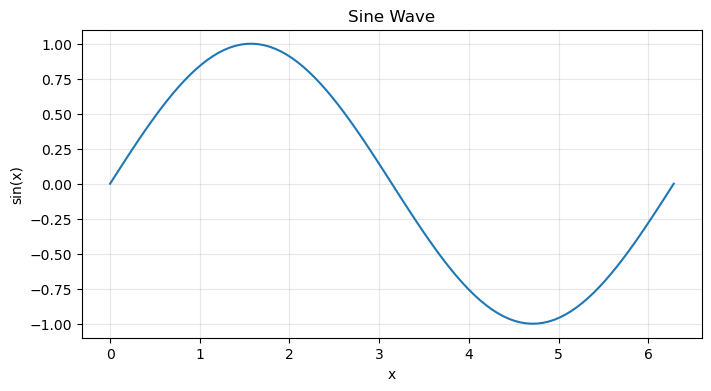

In [43]:
# Generate data using NumPy
x = np.linspace(0, 2 * np.pi, 100)
y = np.sin(x)

# Plot
plt.figure(figsize=(8, 4))
plt.plot(x, y)
plt.title("Sine Wave")
plt.xlabel("x")
plt.ylabel("sin(x)")
plt.grid(True, alpha=0.3)
plt.show()

### Multiple Lines

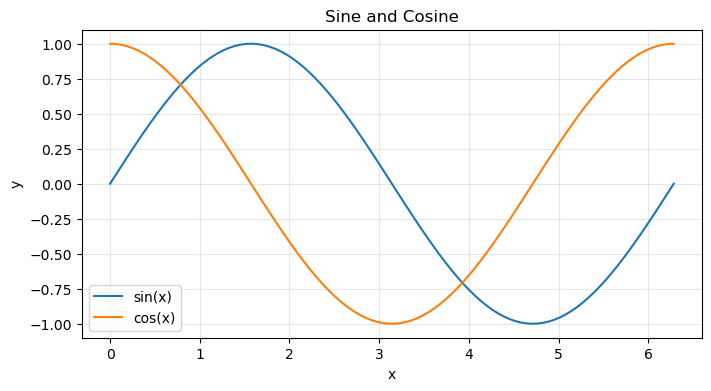

In [44]:
x = np.linspace(0, 2 * np.pi, 100)
y_sin = np.sin(x)
y_cos = np.cos(x)

plt.figure(figsize=(8, 4))
plt.plot(x, y_sin, label="sin(x)")
plt.plot(x, y_cos, label="cos(x)")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Sine and Cosine")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Subplots

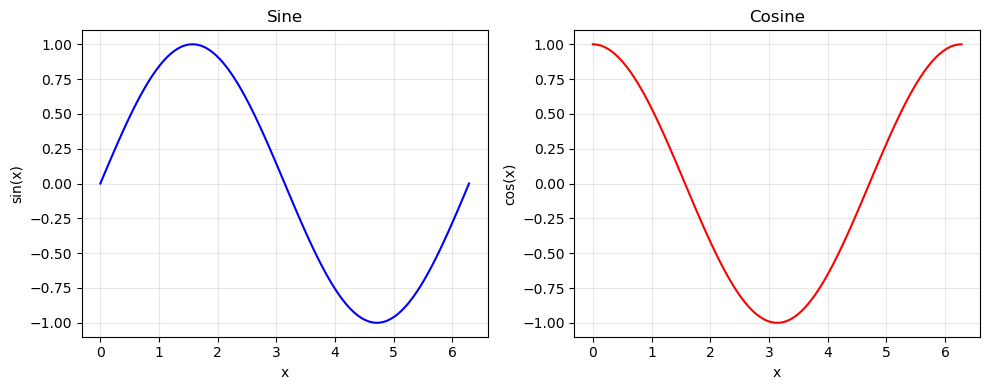

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left plot: Sine wave
axes[0].plot(x, y_sin, color="blue")
axes[0].set_title("Sine")
axes[0].set_xlabel("x")
axes[0].set_ylabel("sin(x)")
axes[0].grid(True, alpha=0.3)

# Right plot: Cosine wave
axes[1].plot(x, y_cos, color="red")
axes[1].set_title("Cosine")
axes[1].set_xlabel("x")
axes[1].set_ylabel("cos(x)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Scatter Plot with NumPy Data

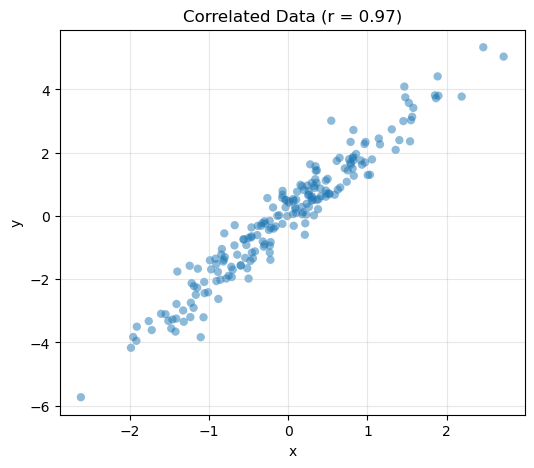

In [46]:
# Generate correlated data
np.random.seed(42)
n = 200
x = np.random.randn(n)
y = 2 * x + np.random.randn(n) * 0.5  # Linear relationship with noise

plt.figure(figsize=(6, 5))
plt.scatter(x, y, alpha=0.5, edgecolors="none")
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Correlated Data (r = {np.corrcoef(x, y)[0, 1]:.2f})")
plt.grid(True, alpha=0.3)
plt.show()

## Working with pandas

NumPy arrays are the engine underneath pandas DataFrames. Understanding NumPy helps you understand what pandas is doing:

In [47]:
import pandas as pd

# Create a NumPy array and convert to DataFrame
data = np.array([[150, 65],
                 [165, 72],
                 [180, 85],
                 [155, 58],
                 [175, 78]])

df = pd.DataFrame(data, columns=["height_cm", "weight_kg"])
print("DataFrame from NumPy array:")
print(df)

# The underlying data is still a NumPy array
print(f"\nUnderlying values: {df['height_cm'].values}")
print(f"Type: {type(df['height_cm'].values)}")

DataFrame from NumPy array:
   height_cm  weight_kg
0        150         65
1        165         72
2        180         85
3        155         58
4        175         78

Underlying values: [150 165 180 155 175]
Type: <class 'numpy.ndarray'>


In [48]:
# Convert DataFrame back to NumPy array
array = df.values
print(f"DataFrame → NumPy array:\n{array}")
print(f"Shape: {array.shape}")
print(f"Type: {type(array)}")

# Now you can use all NumPy operations
print(f"\nColumn means: {array.mean(axis=0).round(1)}")
print(f"Column stds:  {array.std(axis=0).round(1)}")

DataFrame → NumPy array:
[[150  65]
 [165  72]
 [180  85]
 [155  58]
 [175  78]]
Shape: (5, 2)
Type: <class 'numpy.ndarray'>

Column means: [165.   71.6]
Column stds:  [11.4  9.5]


## Summary

You've covered the essential NumPy concepts:

- **Creating arrays** — `np.array()`, `np.zeros()`, `np.ones()`, `np.arange()`, `np.linspace()`
- **Indexing** — slicing, integer indexing, boolean indexing
- **Array math** — elementwise operations, `@` for matrix multiplication
- **Aggregation** — `sum()`, `mean()`, `max()`, `min()`, `std()` with `axis`
- **Broadcasting** — doing math between different-shaped arrays
- **Reshaping** — `reshape()`, `flatten()`, `T` for transpose
- **Visualization** — plotting NumPy data with matplotlib

The key takeaway: **avoid Python loops**. If you find yourself writing a `for` loop over array elements, there's almost certainly a vectorized NumPy way to do it faster.

### Quick Reference

| Task | NumPy approach |
|------|---------------|
| Create array from list | `np.array([1, 2, 3])` |
| Array of zeros | `np.zeros((rows, cols))` |
| Evenly spaced values | `np.linspace(start, stop, num)` |
| Filter elements | `arr[arr > threshold]` |
| Row/column sums | `arr.sum(axis=1)` / `arr.sum(axis=0)` |
| Reshape | `arr.reshape(new_shape)` |
| Transpose | `arr.T` |
| Matrix multiply | `A @ B` |
| Elementwise multiply | `A * B` |
| Broadcast vector to rows | `matrix + vector` |

In the next session, we'll see how pandas builds on NumPy to make data manipulation even more convenient.